In [72]:
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn import tree
import matplotlib.pyplot as plt
from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KNeighborsClassifier

In [73]:
clf = tree.DecisionTreeClassifier()
clf.fit(data22.drop(columns = "Dropout (1=Yes 0=No)"), data22["Dropout (1=Yes 0=No)"]) 
param_grid = {'max_leaf_nodes': range(2, clf.tree_.n_leaves + 1)}


In [74]:
data22 = pd.read_csv(r"../Data/dropout_clean.csv")
data22.to_csv(r"../Data/dropout_clean.csv", index=False)

In [75]:
clf_grid = GridSearchCV(clf, param_grid)

In [76]:
clf_grid.fit(data22.drop(columns = "Dropout (1=Yes 0=No)"), data22["Dropout (1=Yes 0=No)"]) 

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",DecisionTreeClassifier()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_leaf_nodes': range(2, 430)}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",None
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displayed;- >3 : the fold and candidate pa

In [77]:
path = clf.cost_complexity_pruning_path(data22.drop(columns = "Dropout (1=Yes 0=No)"), data22["Dropout (1=Yes 0=No)"])
path

{'ccp_alphas': array([0.00000000e+00, 4.35401978e-05, 7.09769002e-05, 7.14377892e-05,
        7.18322871e-05, 7.19447671e-05, 7.23160870e-05, 7.23464210e-05,
        7.24652865e-05, 7.25233265e-05, 8.16637631e-05, 8.20069910e-05,
        8.56562137e-05, 9.12405370e-05, 9.43670151e-05, 9.67866822e-05,
        9.79965157e-05, 9.79965157e-05, 9.79965157e-05, 9.89863795e-05,
        9.94167550e-05, 9.98112660e-05, 1.00509247e-04, 1.01107516e-04,
        1.01626016e-04, 1.01626016e-04, 1.01626016e-04, 1.02079704e-04,
        1.02480016e-04, 1.03440767e-04, 1.03440767e-04, 1.03573840e-04,
        1.03700017e-04, 1.03700017e-04, 1.03802568e-04, 1.04348142e-04,
        1.04482017e-04, 1.05682517e-04, 1.05774017e-04, 1.05942179e-04,
        1.06146160e-04, 1.06162892e-04, 1.06292517e-04, 1.06600755e-04,
        1.06974754e-04, 1.07039509e-04, 1.07306974e-04, 1.08445965e-04,
        1.08668843e-04, 1.08885017e-04, 1.08885017e-04, 1.08885017e-04,
        1.08885017e-04, 1.08885017e-04, 1.08885017

param_grid = {'ccp_alpha': path['ccp_alphas']}

clf_grid = GridSearchCV(clf, param_grid)

clf_grid.fit(data22.drop(columns = "Dropout (1=Yes 0=No)"), data22["Dropout (1=Yes 0=No)"]) 

In [78]:
columns = data22.columns.drop("Dropout (1=Yes 0=No)")

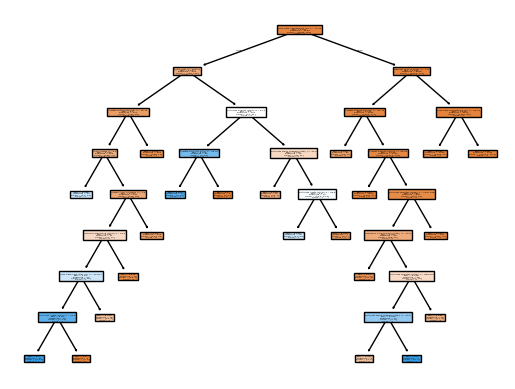

In [83]:
tree.plot_tree(clf_grid.best_estimator_, feature_names=columns, class_names = ["0", "1"], filled = True)
# Source - https://stackoverflow.com/a/39870740
# Posted by Ohad Eytan, modified by community. See post 'Timeline' for change history
# Retrieved 2026-06-24, License - CC BY-SA 4.0

plt.savefig('../Figures/BestTree.png', dpi=500)